## Create a dataframe where each user in the test group has the average difference, the number of pageviews, and the number of commits.
Do not take project1 into account when calculating the average difference and number of commits.
Take the number of commits from the checker table.
The fig size remains the same. You can choose whatever font size and color palette you like.
The size of the dots should be 200.
The width of the lines of the diagonal graphs (KDE) should be 3.
At the end of your Jupyter Notebook, create a Markdown cell and insert the following questions:
"Can we say that if a user has a low number of pageviews, then they likely have a low number of commits?" The answer is yes or no.
"Can we say that if a user has a low number of pageviews, then they likely have a small average difference between the first commit and the lab deadline?" The answer is yes or no.
"Can we say that there are many users with a low number of commits and a few with a high number of commits?" The answer is yes or no.
"Can we say that there are many users with a small average difference and a few with a large average difference?" The answer is yes or no.


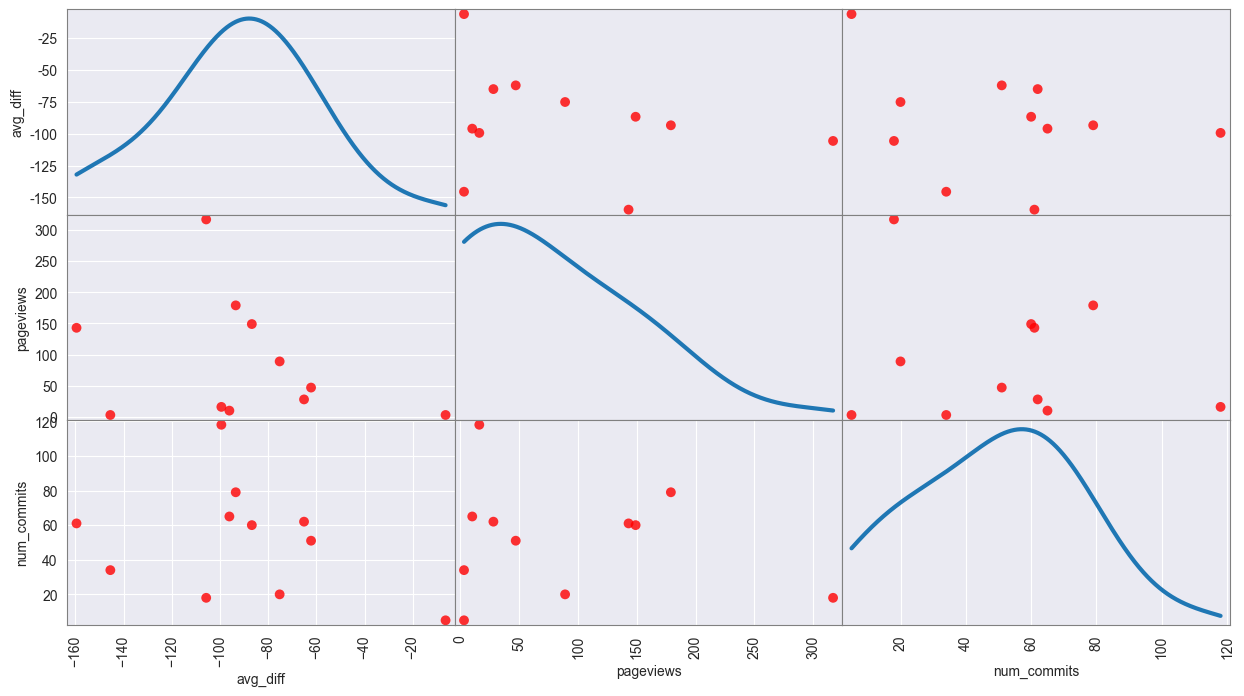

In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix
conn = sqlite3.connect('../data/checking-logs.sqlite')


query = "SELECT uid, (AVG((deadlines - strftime('%s',first_commit_ts))/3600.0))*(-1) as avg_diff FROM test t LEFT JOIN deadlines d ON t.labname = d.labs WHERE t.labname NOT LIKE 'project1' GROUP BY uid;"
avg_diff = pd.read_sql_query(query, conn)

query = " SELECT * FROM checker WHERE uid LIKE 'user_%' AND labname NOT LIKE 'project1'"
commits = pd.read_sql_query(query, conn)
commits = commits.groupby('uid').size().reset_index(name='num_commits')
query = "SELECT * FROM pageviews WHERE uid LIKE 'user_%'"
pageviews = pd.read_sql_query(query, conn)
pageviews = pageviews.groupby('uid').size().reset_index(name='pageviews')

combo = pd.merge(avg_diff, pageviews, on = 'uid', how = 'left')
combo = pd.merge(combo, commits, on = 'uid', how = 'left')
axes = scatter_matrix(
    combo,
    figsize=(15, 8),
    diagonal='kde',
    alpha=0.8,
    s=200,
    color='red'
)

# на диагонали увеличиваем толщину линии KDE
for i in range(len(axes)):
    ax = axes[i, i]
    for line in ax.lines:
        line.set_linewidth(3)

# лёгкая настройка внешнего вида
for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(labelsize=10)
        for spine in ax.spines.values():
            spine.set_color('gray')

## Можно ли утверждать, что если у пользователя мало просмотров страниц, то, вероятно, у него и мало коммитов?

Ответ: нет


## Можно ли утверждать, что если у пользователя мало просмотров страниц, то, вероятно, средняя разница между первым коммитом и крайним сроком выполнения лабораторной работы невелика?

Ответ: нет

## Можно ли сказать, что существует много пользователей с небольшим количеством коммитов и лишь немногие с большим количеством коммитов?

Ответ: да

## Можно ли сказать, что у многих пользователей средняя разница невелика, а у немногих — большая?

Ответ: нет